# SECCIÓN 2: PREPROCESAMIENTO DE DATOS 

Se desarrolla en las subsecciones 6, 7, 8

**OBJETIVO**: Preparar los datos para modelado mediante tratamiento de missing
values, codificación, normalización, split train/test y PCA.


## Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import json
import pickle
import os
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42
TARGET_COLUMN = 'DESEMP_INGLES'

# Crear directorios necesarios
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../outputs/seccion2').mkdir(parents=True, exist_ok=True)

print(f"Random State: {RANDOM_STATE}")
print(f"Variable Objetivo: {TARGET_COLUMN}\n")

Random State: 42
Variable Objetivo: DESEMP_INGLES



### CARGANDO DATOS Y VARIABLES SELECCIONADAS

In [2]:
# Cargar dataset
try:
    df = pd.read_csv('../data/raw/dataset_saber11_reducido_estratificado.csv')
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
except FileNotFoundError:
    print("Error: No se encontró el dataset.")
    raise

# Cargar variables seleccionadas
try:
    with open('../outputs/seccion1/checkpoint_seccion1_completa.json', 'r') as f:
        checkpoint = json.load(f)
    selected_features = checkpoint['variables_seleccionadas_modelado']
    print(f"\nVariables seleccionadas: {len(selected_features)}")
except:
    selected_features = [
        'PUNT_GLOBAL', 'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA',
        'PUNT_SOCIALES_CIUDADANAS', 'PUNT_MATEMATICAS',
        'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR', 'COLE_NATURALEZA',
        'FAMI_TIENEAUTOMOVIL', 'FAMI_EDUCACIONMADRE'
    ]

# Verificar variables
selected_features = [v for v in selected_features if v in df.columns]
df_model = df[selected_features + [TARGET_COLUMN]].copy()

print(f"Dataset para modelado: {df_model.shape}")
display(df_model.head())


Dataset cargado: 217,581 filas × 51 columnas

Variables seleccionadas: 15
Dataset para modelado: (217581, 16)


,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_SOCIALES_CIUDADANAS,PUNT_MATEMATICAS,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,COLE_NATURALEZA,FAMI_TIENEAUTOMOVIL,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,COLE_JORNADA,COLE_AREA_UBICACION,DESEMP_INGLES
0,303,57,63,60,60,Si,Si,NO OFICIAL,Si,Postgrado,Secundaria (Bachillerato) completa,Si,Estrato 4,COMPLETA,URBANO,B1
1,210,42,59,34,34,NaN,NaN,OFICIAL,NaN,NaN,NaN,NaN,NaN,COMPLETA,RURAL,A-
2,266,51,59,54,49,Si,Si,OFICIAL,Si,Técnica o tecnológica completa,Secundaria (Bachillerato) completa,Si,Estrato 2,TARDE,URBANO,A1
3,233,47,47,46,45,Si,No,OFICIAL,No,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Si,Estrato 2,MAÑANA,URBANO,A1
4,180,33,43,22,48,No,No,OFICIAL,No,Primaria completa,Primaria incompleta,No,Sin Estrato,MAÑANA,RURAL,A-


## 6: Prepocesamiento de datos

Tratamiento, Codificacion Y Normalización de Datos

### 6.1 Análisis de missing values

In [3]:
missing_info = pd.DataFrame({
    'Variable': df_model.columns,
    'N_Missing': df_model.isnull().sum().values,
    'Pct_Missing': (df_model.isnull().sum().values / len(df_model) * 100).round(2)
}).sort_values('N_Missing', ascending=False)

missing_vars = missing_info[missing_info['N_Missing'] > 0]

if len(missing_vars) > 0:
    print("Variables con valores faltantes:\n")
    display(missing_vars)
else:
    print("No hay valores faltantes")

Variables con valores faltantes:



,Variable,N_Missing,Pct_Missing
12,FAMI_ESTRATOVIVIENDA,13663,6.28
5,FAMI_TIENEINTERNET,12214,5.61
10,FAMI_EDUCACIONPADRE,12082,5.55
9,FAMI_EDUCACIONMADRE,12004,5.52
8,FAMI_TIENEAUTOMOVIL,7101,3.26
6,FAMI_TIENECOMPUTADOR,6668,3.06
11,FAMI_TIENELAVADORA,6580,3.02


### 6.2: Clasificar variables

In [4]:
numeric_features = df_model[selected_features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_model[selected_features].select_dtypes(include=['object']).columns.tolist()

print(f"Numéricas: {len(numeric_features)}")
for v in numeric_features:
    print(f"   • {v}")

print(f"\nCategóricas: {len(categorical_features)}")
for v in categorical_features:
    print(f"   • {v} ({df_model[v].nunique()} categorías)")

Numéricas: 5
   • PUNT_GLOBAL
   • PUNT_C_NATURALES
   • PUNT_LECTURA_CRITICA
   • PUNT_SOCIALES_CIUDADANAS
   • PUNT_MATEMATICAS

Categóricas: 10
   • FAMI_TIENEINTERNET (2 categorías)
   • FAMI_TIENECOMPUTADOR (2 categorías)
   • COLE_NATURALEZA (2 categorías)
   • FAMI_TIENEAUTOMOVIL (2 categorías)
   • FAMI_EDUCACIONMADRE (12 categorías)
   • FAMI_EDUCACIONPADRE (12 categorías)
   • FAMI_TIENELAVADORA (2 categorías)
   • FAMI_ESTRATOVIVIENDA (7 categorías)
   • COLE_JORNADA (6 categorías)
   • COLE_AREA_UBICACION (2 categorías)


### 6.3: Imputación de valores faltantes

Se utilizan las siguientes estrategias de imputación:
- Variables numéricas: Media
- Variables categóricas: Moda

In [5]:
df_imputed = df_model.copy()

for col in numeric_features:
    n_missing = df_imputed[col].isnull().sum()
    if n_missing > 0:
        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
        print(f"{col}: Imputados {n_missing} con mediana")

for col in categorical_features:
    n_missing = df_imputed[col].isnull().sum()
    if n_missing > 0:
        mode_val = df_imputed[col].mode()[0] if len(df_imputed[col].mode()) > 0 else 'DESCONOCIDO'
        df_imputed[col].fillna(mode_val, inplace=True)
        print(f"{col}: Imputados {n_missing} con moda")

FAMI_TIENEINTERNET: Imputados 12214 con moda
FAMI_TIENECOMPUTADOR: Imputados 6668 con moda
FAMI_TIENEAUTOMOVIL: Imputados 7101 con moda
FAMI_EDUCACIONMADRE: Imputados 12004 con moda
FAMI_EDUCACIONPADRE: Imputados 12082 con moda
FAMI_TIENELAVADORA: Imputados 6580 con moda
FAMI_ESTRATOVIVIENDA: Imputados 13663 con moda


### 6.4: Codificación de variables categóricas

Se utilizan las siguientes estrategias de codificación:
- Variables ordinales: Ordinal Encoding
- Variables nominales: One-Hot Encoding
- Variables binarias: Label Encoding


Target para la variable objetivo : 
 - A- : 0
 - A1 : 1
 - A2 : 2
 - B+ : 3
 - B1 : 4

In [6]:
df_encoded = df_imputed.copy()
label_encoders = {}
encoded_columns = []

# Codificar target
le_target = LabelEncoder()
df_encoded[TARGET_COLUMN + '_encoded'] = le_target.fit_transform(df_encoded[TARGET_COLUMN])
target_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f"Target: {target_mapping}\n")

# Codificar categóricas
for col in categorical_features:
    n_unique = df_encoded[col].nunique()
    
    if n_unique <= 2:
        le = LabelEncoder()
        df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le
        encoded_columns.append(col + '_encoded')
        print(f"{col}: Label Encoding")
    else:
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        encoded_columns.extend(dummies.columns.tolist())
        print(f"{col}: One-Hot Encoding → {len(dummies.columns)} columnas")

final_features = numeric_features + encoded_columns
print(f"\nFeatures finales: {len(final_features)}")

Target: {'A-': np.int64(0), 'A1': np.int64(1), 'A2': np.int64(2), 'B+': np.int64(3), 'B1': np.int64(4)}

FAMI_TIENEINTERNET: Label Encoding
FAMI_TIENECOMPUTADOR: Label Encoding
COLE_NATURALEZA: Label Encoding
FAMI_TIENEAUTOMOVIL: Label Encoding
FAMI_EDUCACIONMADRE: One-Hot Encoding → 11 columnas
FAMI_EDUCACIONPADRE: One-Hot Encoding → 11 columnas
FAMI_TIENELAVADORA: Label Encoding
FAMI_ESTRATOVIVIENDA: One-Hot Encoding → 6 columnas
COLE_JORNADA: One-Hot Encoding → 5 columnas
COLE_AREA_UBICACION: Label Encoding

Features finales: 44


### 6.5: Normalización

Se utiliza StandardScaler para normalizar las variables numéricas.

In [7]:
X = df_encoded[final_features].copy()
y = df_encoded[TARGET_COLUMN + '_encoded'].copy()
y_original = df_encoded[TARGET_COLUMN].copy()

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

print("StandardScaler aplicado")
print("\nEstadísticas post-escalado:\n")
display(X_scaled[numeric_features].describe().round(3))

# Guardar objetos
preprocessing_objects = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'label_encoder_target': le_target,
    'target_mapping': target_mapping,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'final_features': final_features
}

with open('../data/processed/preprocessing_objects.pkl', 'wb') as f:
    pickle.dump(preprocessing_objects, f)

print("\n💾 Guardado: preprocessing_objects.pkl")

StandardScaler aplicado

Estadísticas post-escalado:



,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_SOCIALES_CIUDADANAS,PUNT_MATEMATICAS
count,217581.000,217581.000,217581.000,217581.000,217581.000
mean,-0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-4.802,-4.491,-4.965,-3.811,-4.228
25%,-0.767,-0.770,-0.684,-0.762,-0.721
50%,-0.065,-0.026,-0.018,-0.103,0.030
75%,0.695,0.718,0.743,0.721,0.698
max,4.495,4.811,4.548,4.430,4.121



💾 Guardado: preprocessing_objects.pkl


## 7: División de datos en conjuntos de entrenamiento y prueba

Configuración: 70% Train / 30% Test

In [8]:
TEST_SIZE = 0.30
print(f"Estratificación: Por {TARGET_COLUMN}")

Estratificación: Por DESEMP_INGLES


In [9]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

y_train_original = y_original.loc[X_train.index]
y_test_original = y_original.loc[X_test.index]

print(f"Train: {X_train.shape[0]:,} obs ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} obs ({X_test.shape[0]/len(X)*100:.1f}%)")

Train: 152,306 obs (70.0%)
Test:  65,275 obs (30.0%)


### 7.2 Verificación de estratificación

In [10]:
dist_original = y.value_counts(normalize=True).sort_index() * 100
dist_train = y_train.value_counts(normalize=True).sort_index() * 100
dist_test = y_test.value_counts(normalize=True).sort_index() * 100

verification_df = pd.DataFrame({
    'Clase': le_target.inverse_transform(dist_original.index),
    'Original_%': dist_original.values,
    'Train_%': dist_train.values,
    'Test_%': dist_test.values
}).round(2)

display(verification_df)

# Guardar
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_frame(name='target').to_csv('../data/processed/y_train.csv', index=False)
y_test.to_frame(name='target').to_csv('../data/processed/y_test.csv', index=False)

train_test_data = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'y_train_original': y_train_original,
    'y_test_original': y_test_original
}

with open('../data/processed/train_test_split.pkl', 'wb') as f:
    pickle.dump(train_test_data, f)

print("\n💾 Archivos guardados")

,Clase,Original_%,Train_%,Test_%
0,A-,49.52,49.52,49.52
1,A1,28.16,28.16,28.15
2,A2,14.59,14.59,14.60
3,B+,1.34,1.34,1.34
4,B1,6.39,6.39,6.39



💾 Archivos guardados


## 8: Analisis de Componentes Principales (PCA)

In [11]:
# PCA completo
n_components_max = min(X_train.shape[0], X_train.shape[1])
pca_full = PCA(n_components=n_components_max, random_state=RANDOM_STATE)
X_train_pca_full = pca_full.fit_transform(X_train)

explained_variance = pca_full.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

In [12]:
print(f"Varianza explicada (primeras 10 PCs):\n")
for i in range(min(10, len(explained_variance))):
    print(f"   PC {i+1:2d}: {explained_variance[i]:5.2f}% | Acumulada: {cumulative_variance[i]:6.2f}%")

# Seleccionar componentes óptimas
threshold_90 = np.argmax(cumulative_variance >= 90) + 1
optimal_n_components = threshold_90

print(f"\n✅ Componentes óptimas: {optimal_n_components} (explican {cumulative_variance[optimal_n_components-1]:.2f}%)")

Varianza explicada (primeras 10 PCs):

   PC  1: 49.98% | Acumulada:  49.98%
   PC  2:  5.65% | Acumulada:  55.63%
   PC  3:  4.04% | Acumulada:  59.67%
   PC  4:  3.61% | Acumulada:  63.28%
   PC  5:  3.26% | Acumulada:  66.54%
   PC  6:  2.88% | Acumulada:  69.42%
   PC  7:  2.52% | Acumulada:  71.93%
   PC  8:  2.15% | Acumulada:  74.09%
   PC  9:  2.04% | Acumulada:  76.13%
   PC 10:  2.00% | Acumulada:  78.13%

✅ Componentes óptimas: 19 (explican 90.94%)


**Graficas**

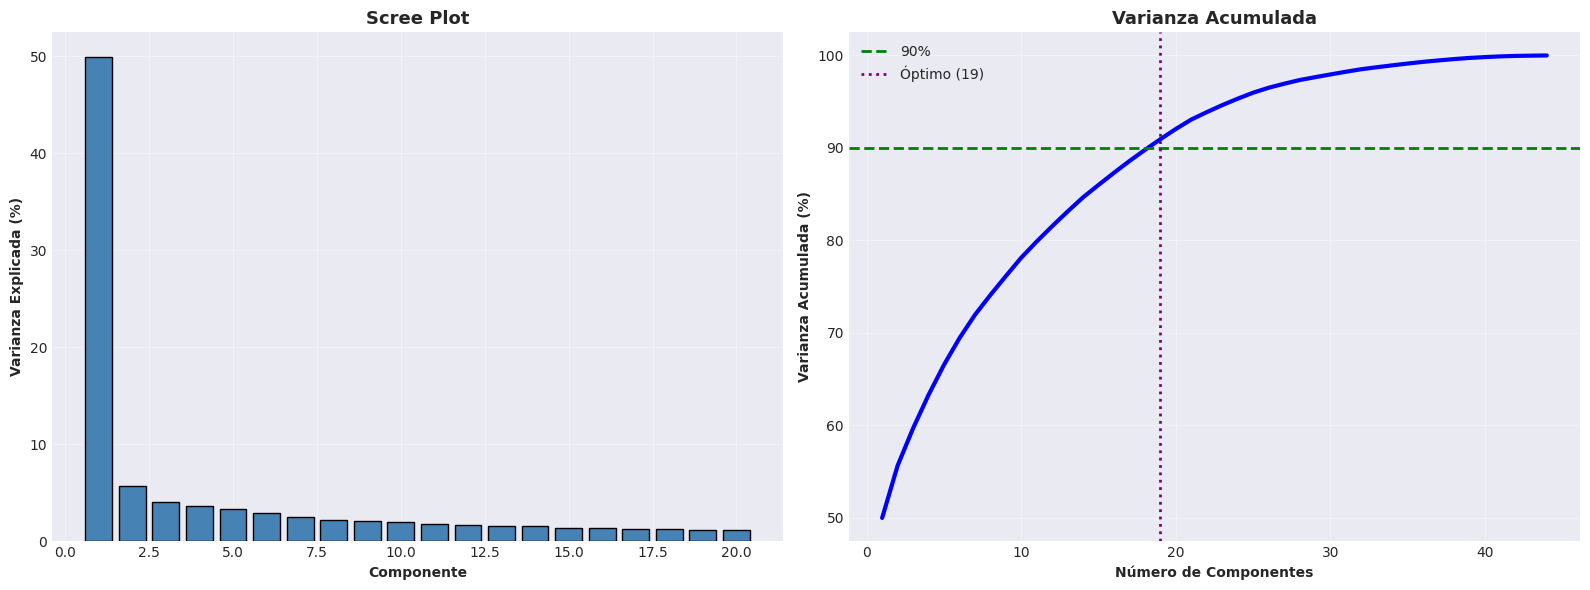


PCA aplicado: (152306, 44) → (152306, 19)
   Reducción: 56.8%


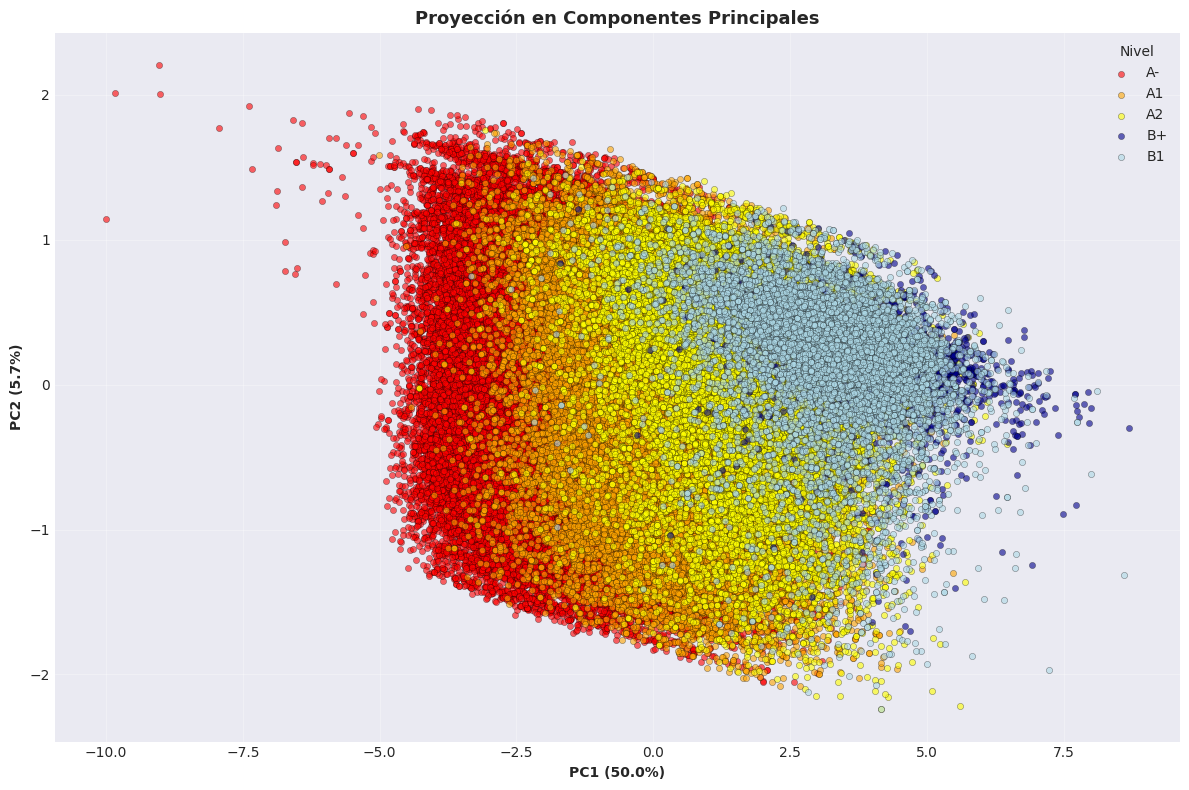

In [13]:
# Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_plot = min(20, len(explained_variance))
axes[0].bar(range(1, n_plot+1), explained_variance[:n_plot], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente', fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)', fontweight='bold')
axes[0].set_title('Scree Plot', fontweight='bold', fontsize=13)
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=3)
axes[1].axhline(y=90, color='green', linestyle='--', linewidth=2, label='90%')
axes[1].axvline(x=optimal_n_components, color='purple', linestyle=':', linewidth=2, label=f'Óptimo ({optimal_n_components})')
axes[1].set_xlabel('Número de Componentes', fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada (%)', fontweight='bold')
axes[1].set_title('Varianza Acumulada', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# PCA óptimo
pca_optimal = PCA(n_components=optimal_n_components, random_state=RANDOM_STATE)
X_train_pca = pca_optimal.fit_transform(X_train)
X_test_pca = pca_optimal.transform(X_test)

print(f"\nPCA aplicado: {X_train.shape} → {X_train_pca.shape}")
print(f"   Reducción: {(1 - optimal_n_components/X_train.shape[1])*100:.1f}%")

# Visualización PC1 vs PC2
fig, ax = plt.subplots(figsize=(12, 8))
colors_map = {'A-': 'red', 'A1': 'orange', 'A2': 'yellow', 'B1': 'lightblue', 'B+': 'darkblue'}

for clase in le_target.classes_:
    mask = y_train_original == clase
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
              c=colors_map[clase], label=clase, alpha=0.6, s=20, edgecolors='black', linewidth=0.3)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1f}%)', fontweight='bold')
ax.set_title('Proyección en Componentes Principales', fontweight='bold', fontsize=13)
ax.legend(title='Nivel')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Guardado: pca_models.pkl, X_train_pca.csv, X_test_pca.csv

In [14]:
pca_objects = {
    'pca_optimal': pca_optimal,
    'optimal_n_components': optimal_n_components,
    'explained_variance': explained_variance,
    'cumulative_variance': cumulative_variance,
    'X_train_pca': X_train_pca,
    'X_test_pca': X_test_pca
}

with open('../data/processed/pca_models.pkl', 'wb') as f:
    pickle.dump(pca_objects, f)

pd.DataFrame(X_train_pca).to_csv('../data/processed/X_train_pca.csv', index=False)
pd.DataFrame(X_test_pca).to_csv('../data/processed/X_test_pca.csv', index=False)

print("Guardado: pca_models.pkl, X_train_pca.csv, X_test_pca.csv")

Guardado: pca_models.pkl, X_train_pca.csv, X_test_pca.csv


In [15]:
# Visualización 3D del PCA - Versión INTERACTIVA (optimizada)
print("📊 Generando visualización 3D interactiva con Plotly...")

fig_plotly = go.Figure()

colors_map = {'A-': 'red', 'A1': 'orange', 'A2': 'yellow', 'B1': 'lightblue', 'B+': 'darkblue'}

for clase in le_target.classes_:
    mask = y_train_original == clase
    fig_plotly.add_trace(go.Scatter3d(
        x=X_train_pca[mask, 0],
        y=X_train_pca[mask, 1],
        z=X_train_pca[mask, 2],
        mode='markers',
        name=clase,
        marker=dict(
            size=3,
            color=colors_map[clase],
            opacity=0.7,
            line=dict(color='white', width=0.5)
        )
    ))

fig_plotly.update_layout(
    title=f'Proyección 3D en Componentes Principales (INTERACTIVA)',
    scene=dict(
        xaxis_title=f'PC1 ({explained_variance[0]:.1f}%)',
        yaxis_title=f'PC2 ({explained_variance[1]:.1f}%)',
        zaxis_title=f'PC3 ({explained_variance[2]:.1f}%)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
        bgcolor='rgba(240,240,240,1)',
        xaxis=dict(backgroundcolor='rgba(240,240,240,1)', gridcolor='white', showbackground=True),
        yaxis=dict(backgroundcolor='rgba(240,240,240,1)', gridcolor='white', showbackground=True),
        zaxis=dict(backgroundcolor='rgba(240,240,240,1)', gridcolor='white', showbackground=True)
    ),
    width=1000,
    height=800,
    showlegend=True,
    legend=dict(title='Nivel'),
    paper_bgcolor='white'
)

fig_plotly.show()

print(f"\n✅ Visualización 3D INTERACTIVA completada con Plotly")
print(f"   Las primeras 3 componentes explican: {cumulative_variance[2]:.2f}% de la varianza")
print(f"\n💡 CONTROLES INTERACTIVOS:")
print(f"   🖱️  Click + arrastrar: Rotar el gráfico en 3D")
print(f"   🔍  Scroll: Zoom in/out")
print(f"   📸  Botones superiores: Guardar, zoom, pan, rotar, resetear")
print(f"   👆  Click en leyenda: Mostrar/ocultar clases")
print(f"   🎯  Hover: Ver valores exactos de cada punto")

📊 Generando visualización 3D interactiva con Plotly...



✅ Visualización 3D INTERACTIVA completada con Plotly
   Las primeras 3 componentes explican: 59.67% de la varianza

💡 CONTROLES INTERACTIVOS:
   🖱️  Click + arrastrar: Rotar el gráfico en 3D
   🔍  Scroll: Zoom in/out
   📸  Botones superiores: Guardar, zoom, pan, rotar, resetear
   👆  Click en leyenda: Mostrar/ocultar clases
   🎯  Hover: Ver valores exactos de cada punto
